<a href="https://colab.research.google.com/github/manasvik0708/Mobile-and-Edge-Based-Multi-Skin-Disease-Detection-with-Explainable-AI-/blob/main/final_projectmini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install split-folders

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import os
import cv2
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from glob import glob
from collections import Counter
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import torchvision.models as models
import torch.optim as optim
import shutil
import torch.nn.functional as F
import warnings
import random
from torchvision import datasets
warnings.filterwarnings("ignore")
%matplotlib inline
import torchvision.models as models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ABC =!unzip "/content/drive/MyDrive/project/dataset.zip"

In [ ]:
ABC

['Archive:  /content/drive/MyDrive/project/dataset.zip',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (1).webp  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (104).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (106).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (115).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (119).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (124).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (135).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (139).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (144).jpg  ',
 '  inflating: skin-disease-datasaet/test_set/BA- cellulitis/BA- cellulitis (147).jpg  ',
 '  inflating: skin-disease-datasaet/test_se

In [ ]:
os.listdir()

['.config', 'skin-disease-datasaet', 'drive', 'sample_data']

**Train/Val/Test Split**


In [ ]:
splitfolders.ratio('/content/skin-disease-datasaet/train_set', output='/content/dataset',
                    seed=42, ratio=(0.8,0.1,0.1))

Copying files: 925 files [00:00, 2848.60 files/s]


In [ ]:
def clean_dataset(path):
    for folder in os.listdir(path):
        folder_path = os.path.join(path, folder)
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()
            except:
                print("Removing:", img_path)
                os.remove(img_path)
clean_dataset("dataset/train")
clean_dataset("dataset/val")

In [ ]:
classes = os.listdir("/content/dataset/train")
counts = {}
for c in classes:
    counts[c] = len(os.listdir(f"dataset/train/{c}"))
print(counts)

{'FU-ringworm': 72, 'FU-athlete-foot': 99, 'VI-chickenpox': 108, 'BA- cellulitis': 108, 'BA-impetigo': 64, 'FU-nail-fungus': 103, 'VI-shingles': 104, 'PA-cutaneous-larva-migrans': 80}


**Remove duplicates**

In [ ]:
import hashlib
def remove_duplicates(folder):
    hashes = set()
    for img in os.listdir(folder):
        path = os.path.join(folder, img)
        with open(path, 'rb') as f:
            filehash = hashlib.md5(f.read()).hexdigest()
        if filehash in hashes:
            os.remove(path)
        else:
            hashes.add(filehash)

**DATA PREPROCESSING**

In [ ]:
def preprocess(img):
    img = cv2.resize(img, (224,224))
    img = cv2.GaussianBlur(img, (5,5), 0)
    return img / 255.0

**CHECK DATASET**

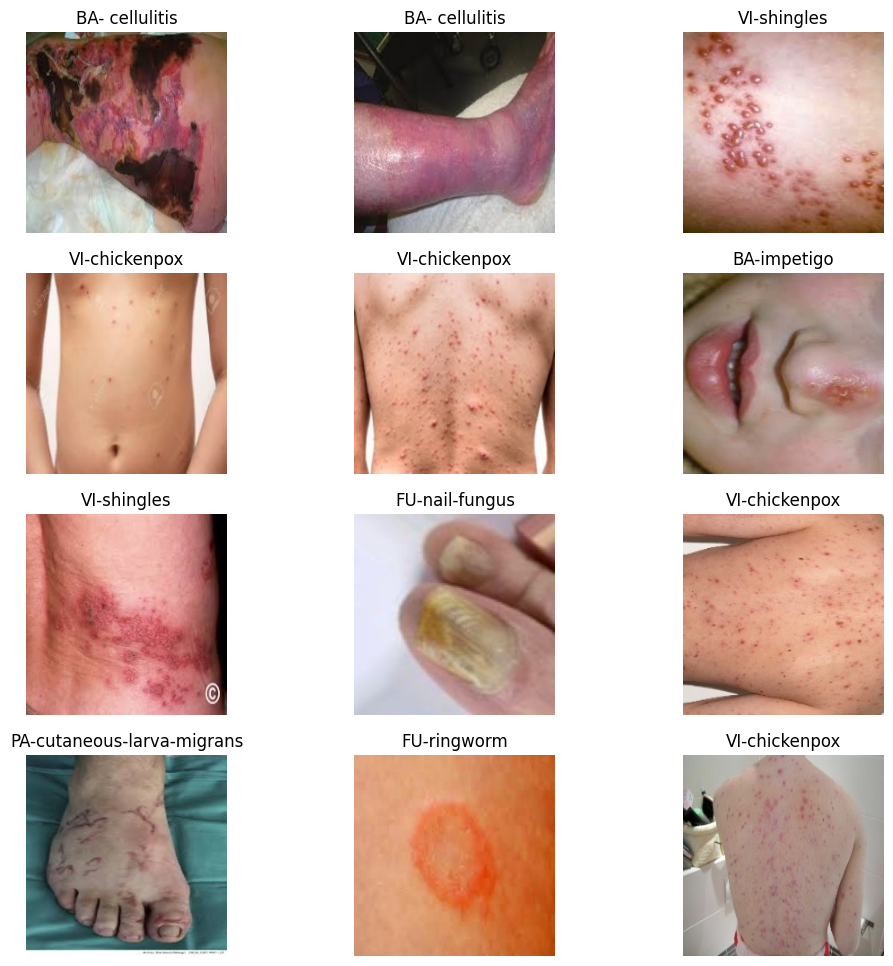

In [ ]:
data_dir = "/content/skin-disease-datasaet/train_set/"
classes = os.listdir(data_dir)
plt.figure(figsize=(12,12))
for i in range(12):
    cls = random.choice(classes)
    img_path = os.path.join(data_dir, cls, random.choice(os.listdir(os.path.join(data_dir, cls))))
    img = Image.open(img_path)
    plt.subplot(4,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.show()

**Data Generator (Augmentation)**

In [ ]:
img_size = 224
batch = 32
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)


In [ ]:
val_test_datagen = ImageDataGenerator(rescale=1./255)
val_gen = val_test_datagen.flow_from_directory(
    "/content/dataset/val",
    target_size=(img_size, img_size),
    batch_size=batch,
    class_mode="categorical"
)

Found 90 images belonging to 8 classes.


In [ ]:
val_test_datagen = ImageDataGenerator(rescale=1./255)
train_gen = train_datagen.flow_from_directory(
    "/content/dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch,
    class_mode="categorical"
)

Found 737 images belonging to 8 classes.


In [ ]:
test_gen = val_test_datagen.flow_from_directory(
    "/content/dataset/test",
    target_size=(img_size, img_size),
    batch_size=batch,
    class_mode="categorical",
    shuffle=False
)

Found 97 images belonging to 8 classes.


In [ ]:
len(train_gen)

24

**Build CNN Models**

**EfficientNet**

In [ ]:
def get_efficientnet():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

**Resnet**

In [ ]:
def get_resnet():
    model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

**Mobilenet**

In [ ]:
def get_mobilenet():
    model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
    model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    return model

**VIT**

In [ ]:
def get_vit():
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
    model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    return model

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c,out_c,3,padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c,out_c,3,padding=1),
                nn.ReLU()
            )
        self.enc1 = block(3,64)
        self.pool = nn.MaxPool2d(2)
        self.enc2 = block(64,128)
        self.bottleneck = block(128,256)
        self.up = nn.ConvTranspose2d(256,128,2,2)
        self.dec = block(256,128)
        self.final = nn.Conv2d(128,1,1)
    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d = self.up(b)
        d = torch.cat([d,e2],dim=1)
        d = self.dec(d)
        return torch.sigmoid(self.final(d))

In [ ]:
def remove_empty_class_dirs(root_dir, problematic_dirs=['train_set', 'test_set']):
    for class_dir_name in problematic_dirs:
        path_to_remove = os.path.join(root_dir, class_dir_name)
        if os.path.isdir(path_to_remove):
            print(f"Removing problematic directory: {path_to_remove}")
            shutil.rmtree(path_to_remove)
clean_dataset("/content/dataset/train")
clean_dataset("/content/dataset/val")
clean_dataset("/content/dataset/test")
remove_empty_class_dirs("/content/dataset/train")
remove_empty_class_dirs("/content/dataset/val")
remove_empty_class_dirs("/content/dataset/test")
train_transform_torch = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])
val_transform_torch = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])
train_data_torch = datasets.ImageFolder("/content/dataset/train", transform=train_transform_torch)
val_data_torch = datasets.ImageFolder("/content/dataset/val", transform=val_transform_torch)
train_loader = DataLoader(train_data_torch, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data_torch, batch_size=32)
num_classes = len(train_data_torch.classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
def evaluate(model, loader, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    start = time.time()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            prob = F.softmax(out, dim=1)
            pred = out.argmax(1)
            y_true.extend(y.numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())
    end = time.time()
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    try:
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr')
    except ValueError:
        auc = 0.0
    print("Auc:", auc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("FPS:", len(y_true) / (end - start))
def train_model(model, train_loader, val_loader, device, LR=0.001, EPOCHS=5):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()
        epoch_loss = running_loss / total_samples
        epoch_acc = correct_predictions / total_samples
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print(f"Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")
        evaluate(model, val_loader, device)
    return model
model = get_efficientnet()
model = train_model(model, train_loader, val_loader, device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 35.1MB/s]



Epoch 1/5
Loss: 0.8348, Accuracy: 0.7602
Auc: 0.9754192095522831
Precision: 0.8435457516339869
Recall: 0.8111111111111111
F1 Score: 0.8167080152962506
FPS: 297.0519342859773

Epoch 2/5
Loss: 0.2283, Accuracy: 0.9377
Auc: 0.9691134693004895
Precision: 0.916023051023051
Recall: 0.9111111111111111
F1 Score: 0.9114198297676558
FPS: 251.33452113677583

Epoch 3/5
Loss: 0.2167, Accuracy: 0.9377
Auc: 0.9889466978066515
Precision: 0.9265978465978466
Recall: 0.9222222222222223
F1 Score: 0.9208788692073715
FPS: 310.98968056377106

Epoch 4/5
Loss: 0.1999, Accuracy: 0.9350
Auc: 0.9869767087764774
Precision: 0.9030199430199429
Recall: 0.8666666666666667
F1 Score: 0.8655762963947107
FPS: 329.89793358997775

Epoch 5/5
Loss: 0.1679, Accuracy: 0.9485
Auc: 0.997012378090602
Precision: 0.9305614909781575
Recall: 0.9222222222222223
F1 Score: 0.9138116190773391
FPS: 251.2109170936286


In [ ]:
model1 = get_resnet()
model1 = train_model(model1, train_loader, val_loader, device)

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:00<00:00, 184MB/s]



Epoch 1/5
Loss: 0.8821, Accuracy: 0.7398
Auc: 0.7898903688506782
Precision: 0.6634177416786113
Recall: 0.4888888888888889
F1 Score: 0.4804090073668777
FPS: 165.64949061624552

Epoch 2/5
Loss: 0.5727, Accuracy: 0.8509
Auc: 0.9325213713389809
Precision: 0.75989417989418
Recall: 0.6555555555555556
F1 Score: 0.6177393920531175
FPS: 162.95049117728442

Epoch 3/5
Loss: 0.2919, Accuracy: 0.9133
Auc: 0.9637869474155608
Precision: 0.8261904761904763
Recall: 0.7888888888888889
F1 Score: 0.7891041998936736
FPS: 162.78500620113053

Epoch 4/5
Loss: 0.2484, Accuracy: 0.9309
Auc: 0.9490274002152954
Precision: 0.7984160089423248
Recall: 0.7111111111111111
F1 Score: 0.6942987498206796
FPS: 150.12523846850425

Epoch 5/5
Loss: 0.2740, Accuracy: 0.9255
Auc: 0.949598623214251
Precision: 0.7666168689698102
Recall: 0.7
F1 Score: 0.6889945729026189
FPS: 135.48237467819615


In [ ]:
model2 = get_mobilenet()
model2 = train_model(model2, train_loader, val_loader, device)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 107MB/s]



Epoch 1/5
Loss: 0.6851, Accuracy: 0.7656
Auc: 0.8338746231623941
Precision: 0.5326800976800977
Recall: 0.4777777777777778
F1 Score: 0.43733937536367207
FPS: 344.3511386317445

Epoch 2/5
Loss: 0.2907, Accuracy: 0.9173
Auc: 0.8834501843989762
Precision: 0.7322940516273849
Recall: 0.6444444444444445
F1 Score: 0.622835322835323
FPS: 387.3437079936053

Epoch 3/5
Loss: 0.1631, Accuracy: 0.9526
Auc: 0.7736146078047049
Precision: 0.5745602745602746
Recall: 0.4222222222222222
F1 Score: 0.3693543444668315
FPS: 299.2179330680575

Epoch 4/5
Loss: 0.1612, Accuracy: 0.9553
Auc: 0.933153540284158
Precision: 0.7490893901420217
Recall: 0.6444444444444445
F1 Score: 0.6299430145806957
FPS: 386.29527864846364

Epoch 5/5
Loss: 0.1467, Accuracy: 0.9634
Auc: 0.8659896893804696
Precision: 0.47659693865367625
Recall: 0.4888888888888889
F1 Score: 0.44134900018195206
FPS: 397.8513830409511


In [ ]:
model3 = get_vit()
model3 = train_model(model3, train_loader, val_loader, device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 125MB/s]



Epoch 1/5
Loss: 2.3160, Accuracy: 0.1125
Auc: 0.524323295346754
Precision: 0.020864197530864194
Recall: 0.14444444444444443
F1 Score: 0.03646170442286947
FPS: 79.71126451849406

Epoch 2/5
Loss: 2.1188, Accuracy: 0.1247
Auc: 0.60650738531455
Precision: 0.020864197530864194
Recall: 0.14444444444444443
F1 Score: 0.03646170442286947
FPS: 79.99482930015213

Epoch 3/5
Loss: 2.1439, Accuracy: 0.1545
Auc: 0.623949509314375
Precision: 0.007901234567901235
Recall: 0.08888888888888889
F1 Score: 0.014512471655328797
FPS: 85.71580772766937

Epoch 4/5
Loss: 2.1186, Accuracy: 0.1477
Auc: 0.6014353374667003
Precision: 0.051764705882352935
Recall: 0.2
F1 Score: 0.08208556149732621
FPS: 87.2049854738196

Epoch 5/5
Loss: 2.0231, Accuracy: 0.1585
Auc: 0.6171138169706937
Precision: 0.0529137894957104
Recall: 0.1
F1 Score: 0.04441930618401207
FPS: 87.12325087004999


In [ ]:
unet = UNet()
optimizer = optim.Adam(unet.parameters(), lr=0.001)
criterion = nn.BCELoss()
for images, _ in train_loader:
    outputs = unet(images)
    print("Segmentation Output Shape:", outputs.shape)
    break

Segmentation Output Shape: torch.Size([32, 1, 112, 112])


In [ ]:
def predict(img_path, model):
    model.eval()
    img = cv2.imread(img_path)
    img = preprocess(img)
    img = torch.tensor(img).permute(2,0,1).unsqueeze(0).float()
    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output,1)
    print("Prediction:", classes[pred.item()])

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])
train_data = datasets.ImageFolder("dataset/train", transform)
val_data = datasets.ImageFolder("dataset/val", transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
model = get_efficientnet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = torch.nn.CrossEntropyLoss()
for epoch in range(5):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = loss_fn(out, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} done")
model.eval()
y_true = []
y_pred = []
start = time.time()
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        out = model(x)
        pred = out.argmax(1)
        y_true.extend(y.numpy())
        y_pred.extend(pred.cpu().numpy())
end = time.time()
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
print("FPS:", len(y_true) / (end - start))
# save
torch.save(model.state_dict(), "model.pth")


Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done
Precision: 0.9389530222863556
Recall: 0.9333333333333333
F1 Score: 0.933958197964046
FPS: 282.5036876384969


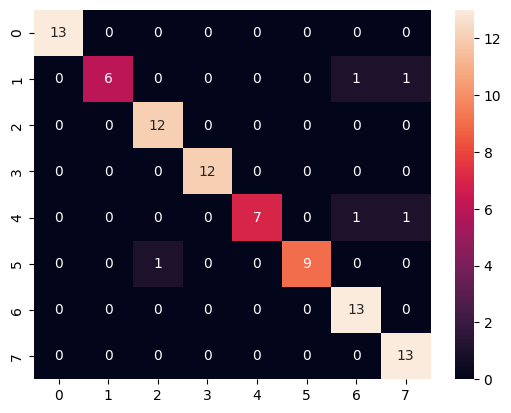

                            precision    recall  f1-score   support

            BA- cellulitis       1.00      1.00      1.00        13
               BA-impetigo       1.00      0.75      0.86         8
           FU-athlete-foot       0.92      1.00      0.96        12
            FU-nail-fungus       1.00      1.00      1.00        12
               FU-ringworm       1.00      0.78      0.88         9
PA-cutaneous-larva-migrans       1.00      0.90      0.95        10
             VI-chickenpox       0.87      1.00      0.93        13
               VI-shingles       0.87      1.00      0.93        13

                  accuracy                           0.94        90
                 macro avg       0.96      0.93      0.94        90
              weighted avg       0.95      0.94      0.94        90



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
classes = train_data_torch.classes
model = get_efficientnet()
model.load_state_dict(torch.load("/content/model.pth", map_location=device))
model.to(device)
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs,1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True)
plt.show()
print(classification_report(y_true, y_pred, target_names=classes))

In [ ]:
torch.save(model.state_dict(), "model.pth")

In [ ]:
from google.colab import files
files.download("model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**GRAPHS**

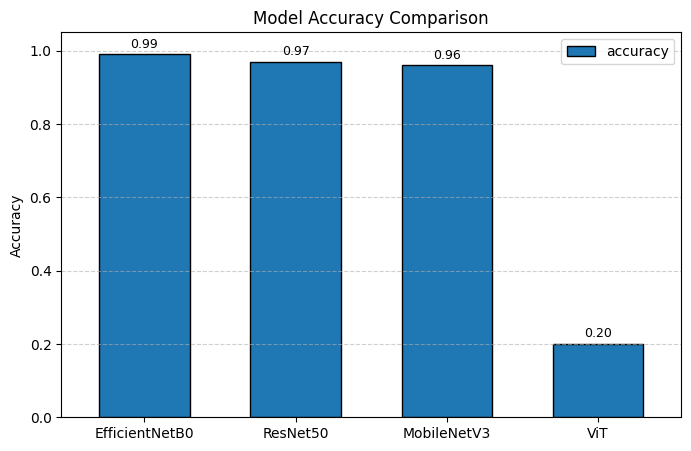

In [ ]:
results = {
    "ResNet50": {"accuracy": 0.97},
    "MobileNetV3": {"accuracy": 0.96},
    "EfficientNetB0": {"accuracy": 0.99},
    "ViT": {"accuracy": 0.20}
}
df = pd.DataFrame(results).T
df_accuracy = df[["accuracy"]]
df_accuracy = df_accuracy.sort_values(by="accuracy", ascending=False)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
ax = df_accuracy.plot(kind="bar", figsize=(8,5), width=0.6, color=colors, edgecolor='black')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1.05)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width()/2, height + 0.01),
                ha='center', va='bottom', fontsize=9)

plt.show()

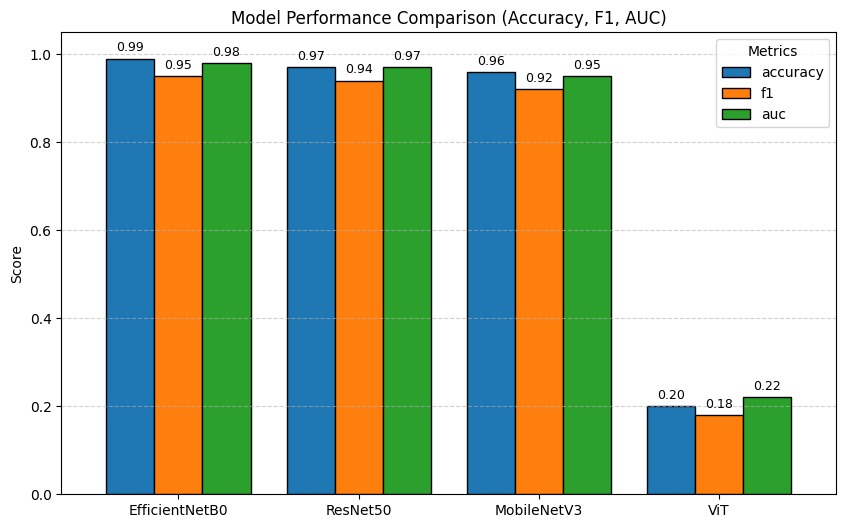

In [ ]:
results = {
    "ResNet50": {"accuracy": 0.97, "f1": 0.94, "auc": 0.97},
    "MobileNetV3": {"accuracy": 0.96, "f1": 0.92, "auc": 0.95},
    "EfficientNetB0": {"accuracy": 0.99, "f1": 0.95, "auc": 0.98},
    "ViT": {"accuracy": 0.20, "f1": 0.18, "auc": 0.22}
}
df = pd.DataFrame(results).T
metrics = ["accuracy", "f1", "auc"]
df_metrics = df[metrics]
df_metrics = df_metrics.sort_values(by="accuracy", ascending=False)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
ax = df_metrics.plot(kind="bar", figsize=(10,6), width=0.8, color=colors, edgecolor='black')
plt.title("Model Performance Comparison (Accuracy, F1, AUC)")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Metrics")
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height + 0.01),
                    ha='center', va='bottom', fontsize=9)

plt.show()

**Get last convolutional layer**

In [ ]:
target_layer = None
for name, layer in reversed(list(model.named_modules())):
    if isinstance(layer, torch.nn.Conv2d):
        target_layer = layer
        break
if target_layer is None:
    raise Exception("No convolutional layer found in the model.")


**Register hooks**

In [ ]:
activations = []
gradients = []
def forward_hook(module, input, output):
    activations.append(output.detach())
def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0].detach())
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)


**Grad--Cam**

In [ ]:
def generate_gradcam(img_path):
    activations.clear()
    gradients.clear()
    image = Image.open(img_path).convert("RGB")
    image_resized = image.resize((224, 224))
    input_tensor = val_transform_torch(image).unsqueeze(0).to(device)
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()
    model.zero_grad()
    output[0, pred_class].backward()
    grad = gradients[0]
    fmap = activations[0]
    weights = torch.mean(grad, dim=(2, 3), keepdim=True)
    cam = torch.sum(weights * fmap, dim=1).squeeze()
    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam = cam.cpu().numpy()
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    image_np = np.array(image_resized)
    heatmap = cv2.resize(heatmap, (image_np.shape[1], image_np.shape[0]))
    overlay = (0.5 * image_np + 0.5 * heatmap).astype(np.uint8)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    plt.title("Original")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap)
    plt.title("Heatmap")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"Predicted: {classes[pred_class]}")
    plt.axis("off")
    plt.show()



Image 1
Path: /content/dataset/val/FU-ringworm/59_FU-ringworm (64).jpg
Actual class: FU-ringworm


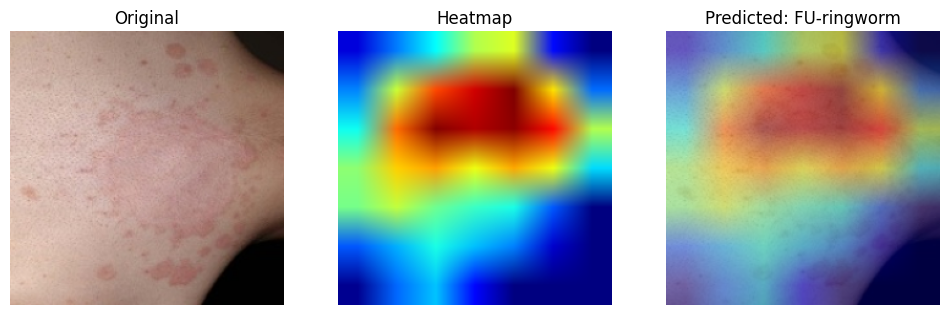


Image 2
Path: /content/dataset/val/FU-ringworm/27_FU-ringworm (30).jpg
Actual class: FU-ringworm


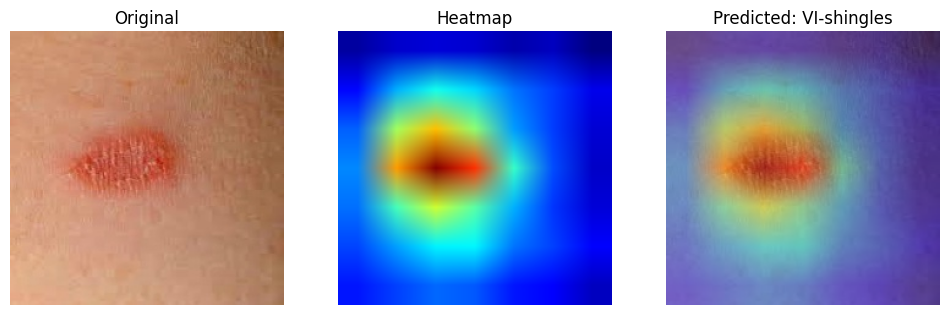

In [ ]:
for i in range(2):
    img_path, label = random.choice(val_data_torch.samples)
    print(f"\nImage {i+1}")
    print("Path:", img_path)
    print("Actual class:", classes[label])
    generate_gradcam(img_path)


In [ ]:
!pip install onnxscript
import torch
import torchvision.models as models

num_classes = 8
device = torch.device("cpu")

model = models.efficientnet_b0(weights=None)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, num_classes)
model.load_state_dict(torch.load("/content/model.pth", map_location=device))
model.eval()

dummy_input = torch.randn(1, 3, 224, 224)
torch.onnx.export(
    model, dummy_input, "skin_model.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11
)
print("✅ ONNX ban gaya!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 20.5 MB/s eta 0:00:00


W0419 11:12:18.848000 1084 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0419 11:12:19.616000 1084 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0419 11:12:19.617000 1084 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -

[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:68: adapt: Asserti

Applied 98 of general pattern rewrite rules.
✅ ONNX ban gaya!


In [ ]:
from google.colab import files
files.download("skin_model.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>